In [1]:
import pandas as pd
import numpy as np
import torch
import random
import evaluate

from datasets import load_dataset, DatasetDict
from transformers import (
    XLNetTokenizer,
    XLNetForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)


In [2]:
from datasets import load_dataset

dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree")

Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at /Users/chausacdin/.cache/huggingface/datasets/takala___financial_phrasebank/sentences_allagree/1.0.0/550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Sat May 30 18:58:55 2026).


In [3]:
dataset["train"][0]

{'sentence': 'According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .',
 'label': 1}

In [4]:
#Train-Test split
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

dataset_dict = DatasetDict({
    "train": split_dataset["train"],
    "test": split_dataset["test"]
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 1811
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 453
    })
})

In [5]:
df = pd.DataFrame(dataset_dict["train"])
df.head()

,sentence,label
0,Koff 's market share of the volume of the mark...,1
1,"The market value of one crane is some USD6m , ...",1
2,Sales by Seppala diminished by 6 per cent .,0
3,"Operating profit was EUR 139.7 mn , up 23 % fr...",2
4,The purchase sum is about EUR 10mn US$ 12.97 mn .,1


In [6]:
# Label Mapping
id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

NUM_LABELS = 3

In [7]:
# tokenizer

tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")


In [8]:
# Tokenize financial news sentences

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

In [9]:
pd.DataFrame(tokenized_datasets["train"])

,sentence,label,input_ids,token_type_ids,attention_mask
0,Koff 's market share of the volume of the mark...,1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"The market value of one crane is some USD6m , ...",1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Sales by Seppala diminished by 6 per cent .,0,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"Operating profit was EUR 139.7 mn , up 23 % fr...",2,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,The purchase sum is about EUR 10mn US$ 12.97 mn .,1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
1806,Finnish investment group Norvestia Oyj said it...,0,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1807,The record date for dividend distribution is M...,1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1808,"YIT CORPORATION SEPT. 24 , 2007 at 13:30 CORPO...",1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1809,Finnish silicon wafer technology company Okmet...,1,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [10]:
# Remove text column and prepare for PyTorch
tokenized_datasets = tokenized_datasets.remove_columns(["sentence"])
tokenized_datasets.set_format("torch")

tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1811
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 453
    })
})

In [11]:
# Load XLNet model
model = XLNetForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# Accuracy Metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

In [13]:
# Training Arguments
# 11. Training arguments
training_args = TrainingArguments(
    output_dir="./xlnet-financial-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True
)

In [14]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/var/folders/15/r_c26kl94td48ryhxtt_kygr0000gn/T/ipykernel_78914/913219649.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.012100,0.265982,0.955850
2,0.011000,0.174030,0.969095
3,0.000900,0.208774,0.969095


TrainOutput(global_step=1359, training_loss=0.15202831118626314, metrics={'train_runtime': 1088.9655, 'train_samples_per_second': 4.989, 'train_steps_per_second': 1.248, 'total_flos': 386941848387840.0, 'train_loss': 0.15202831118626314, 'epoch': 3.0})

In [15]:
# Evaluate
trainer.evaluate()

{'eval_loss': 0.17403003573417664,
 'eval_accuracy': 0.9690949227373068,
 'eval_runtime': 20.9144,
 'eval_samples_per_second': 21.66,
 'eval_steps_per_second': 5.451,
 'epoch': 3.0}

In [16]:
# Save model
model.save_pretrained("fine_tuned_xlnet_financial_sentiment")
tokenizer.save_pretrained("fine_tuned_xlnet_financial_sentiment")

('fine_tuned_xlnet_financial_sentiment/tokenizer_config.json',
 'fine_tuned_xlnet_financial_sentiment/special_tokens_map.json',
 'fine_tuned_xlnet_financial_sentiment/spiece.model',
 'fine_tuned_xlnet_financial_sentiment/added_tokens.json')

In [20]:
# Load fine-tuned model into pipeline
import torch
from transformers import XLNetTokenizer, XLNetForSequenceClassification

model_path = "fine_tuned_xlnet_financial_sentiment"

tokenizer = XLNetTokenizer.from_pretrained(model_path)
model = XLNetForSequenceClassification.from_pretrained(model_path)

model.eval()

XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (sequence_summary): SequenceSummary(
    (summary): Linear(in_features=768, out_features=768, bias=True)
    (activation): Tanh()
    (first_dropout): Identity()
    (last

In [21]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class_id = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class_id].item()

    label = model.config.id2label[predicted_class_id]

    return {
        "text": text,
        "sentiment": label,
        "confidence": confidence
    }

In [23]:
sample_news = [
    "Apple reported stronger than expected quarterly earnings.",
    "Tesla shares dropped after lower vehicle deliveries.",
    "Microsoft announced a major investment in artificial intelligence.",
    "The company warned investors about declining revenue next quarter.",
    "Interest rates remained unchanged by the central bank."
]

for news in sample_news:
    print(news)
    print(predict_sentiment(news))
    print()

Apple reported stronger than expected quarterly earnings.
{'text': 'Apple reported stronger than expected quarterly earnings.', 'sentiment': 'positive', 'confidence': 0.9996920824050903}

Tesla shares dropped after lower vehicle deliveries.
{'text': 'Tesla shares dropped after lower vehicle deliveries.', 'sentiment': 'negative', 'confidence': 0.9998868703842163}

Microsoft announced a major investment in artificial intelligence.
{'text': 'Microsoft announced a major investment in artificial intelligence.', 'sentiment': 'positive', 'confidence': 0.8691501617431641}

The company warned investors about declining revenue next quarter.
{'text': 'The company warned investors about declining revenue next quarter.', 'sentiment': 'negative', 'confidence': 0.9998742341995239}

Interest rates remained unchanged by the central bank.
{'text': 'Interest rates remained unchanged by the central bank.', 'sentiment': 'neutral', 'confidence': 0.9999252557754517}



In [30]:
import pandas as pd

df = pd.read_csv("all_data_no_labels.csv", encoding="latin1")

df.head()

,all_data_no_labels
0,Headline
1,"According to Gran , the company has no plans t..."
2,Technopolis plans to develop in stages an area...
3,The international electronic industry company ...
4,With the new production plant the company woul...


In [43]:
df.columns

Index(['all_data_no_labels'], dtype='object')

In [47]:
df[["sentiment", "confidence"]] = df['all_data_no_labels'].apply(
    lambda x: pd.Series(predict_sentiment(x))
)

df.head()

,all_data_no_labels,sentiment,confidence
0,Headline,neutral,0.999935
1,"According to Gran , the company has no plans t...",neutral,0.999785
2,Technopolis plans to develop in stages an area...,neutral,0.999921
3,The international electronic industry company ...,positive,0.761677
4,With the new production plant the company woul...,positive,0.999918


In [48]:
df.to_csv("classified_headlines.csv", index=False)

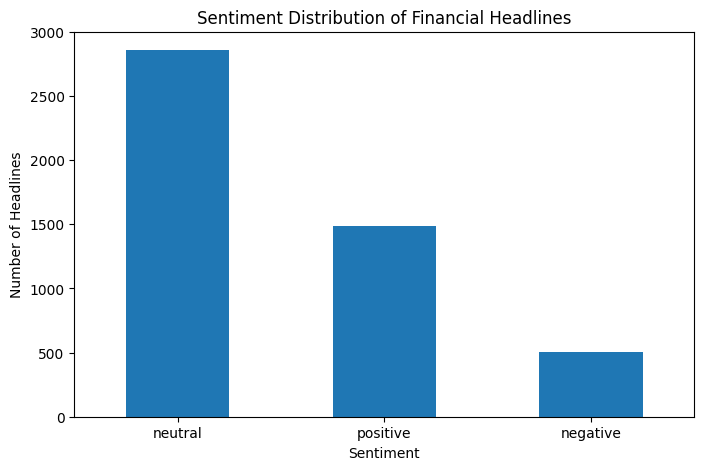

In [49]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution of Financial Headlines")
plt.xlabel("Sentiment")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=0)

plt.show()

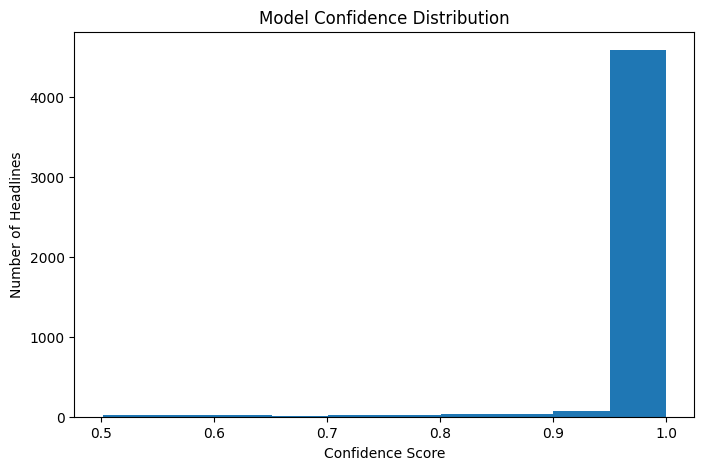

In [50]:
plt.figure(figsize=(8, 5))

df["confidence"].plot(kind="hist", bins=10)

plt.title("Model Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Headlines")

plt.show()

In [51]:
df.groupby("sentiment")["confidence"].mean()

sentiment
negative    0.986718
neutral     0.989955
positive    0.983700
Name: confidence, dtype: float64

In [52]:
df.sort_values("confidence").head(20)

,all_data_no_labels,sentiment,confidence
408,"The new facility , to be known as Technopolis ...",neutral,0.501337
1207,DnB Nord of Norway is the `` most likely Nordi...,positive,0.504078
4520,We offer challenging and interesting employmen...,neutral,0.508159
2024,"Instead , Elcoteq has signed a non-binding Let...",positive,0.512081
4326,"Juhani J+Ãrvi , Corporate Executive Vice Pres...",neutral,0.516726
1962,Our purchase to pay solutions enable companies...,neutral,0.517365
3404,The venture recently agreed to buy Motorola 's...,neutral,0.520537
397,Efore 's CEO Reijo Maihaniemi said that the co...,neutral,0.523775
2458,Finnish industrial group Ruukki Group Plc OMX ...,neutral,0.525106
986,"The launch of the plant in June went well , an...",neutral,0.526836


In [55]:
#Evaluation of the trainer
trainer.evaluate()

{'eval_loss': 0.17403003573417664,
 'eval_accuracy': 0.9690949227373068,
 'eval_runtime': 22.4184,
 'eval_samples_per_second': 20.207,
 'eval_steps_per_second': 5.085,
 'epoch': 3.0}

In [56]:
from sklearn.metrics import classification_report

In [57]:
predictions = trainer.predict(tokenized_datasets["test"])

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        73
           1       0.99      0.97      0.98       280
           2       0.91      0.98      0.94       100

    accuracy                           0.97       453
   macro avg       0.96      0.96      0.96       453
weighted avg       0.97      0.97      0.97       453

